In [14]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('water_potability.csv')

In [3]:
df

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0
...,...,...,...,...,...,...,...,...,...,...
3271,4.668102,193.681735,47580.991603,7.166639,359.948574,526.424171,13.894419,66.687695,4.435821,1
3272,7.808856,193.553212,17329.802160,8.061362,NaN,392.449580,19.903225,NaN,2.798243,1
3273,9.419510,175.762646,33155.578218,7.350233,NaN,432.044783,11.039070,69.845400,3.298875,1
3274,5.126763,230.603758,11983.869376,6.303357,NaN,402.883113,11.168946,77.488213,4.708658,1


In [4]:
df.isnull().sum()

ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64

In [6]:
df['ph'] = df['ph'].fillna(df['ph'].mean())
df['Sulfate'] = df['Sulfate'].fillna(df['Sulfate'].median())
df['Trihalomethanes'] = df['Trihalomethanes'].fillna(df['Trihalomethanes'].median())

In [7]:
print(df.isnull().sum())

ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64


In [8]:
def calculate_risk(row):
    # WHO suggests pH should be between 6.5 and 8.5
    if row['ph'] < 6.5 or row['ph'] > 8.5:
        return 'High Risk'
    if row['Sulfate'] > 250: # Common limit for Sulfate
        return 'Moderate Risk'
    return 'Safe'

df['Risk_Analysis'] = df.apply(calculate_risk, axis=1)

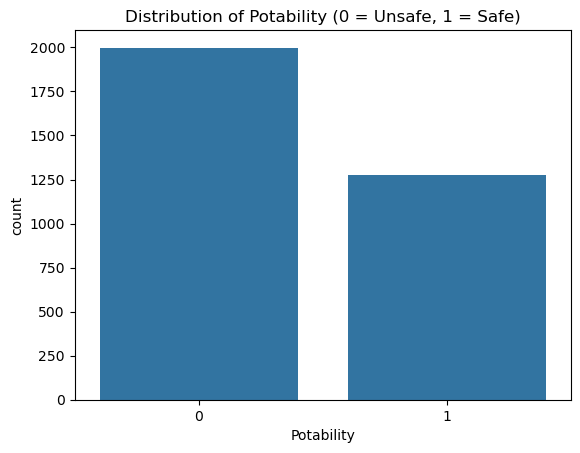

Potability
0    1998
1    1278
Name: count, dtype: int64


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Check if the data is balanced (how many 0s vs 1s)
sns.countplot(x='Potability', data=df)
plt.title('Distribution of Potability (0 = Unsafe, 1 = Safe)')
plt.show()

# Print the exact counts
print(df['Potability'].value_counts())

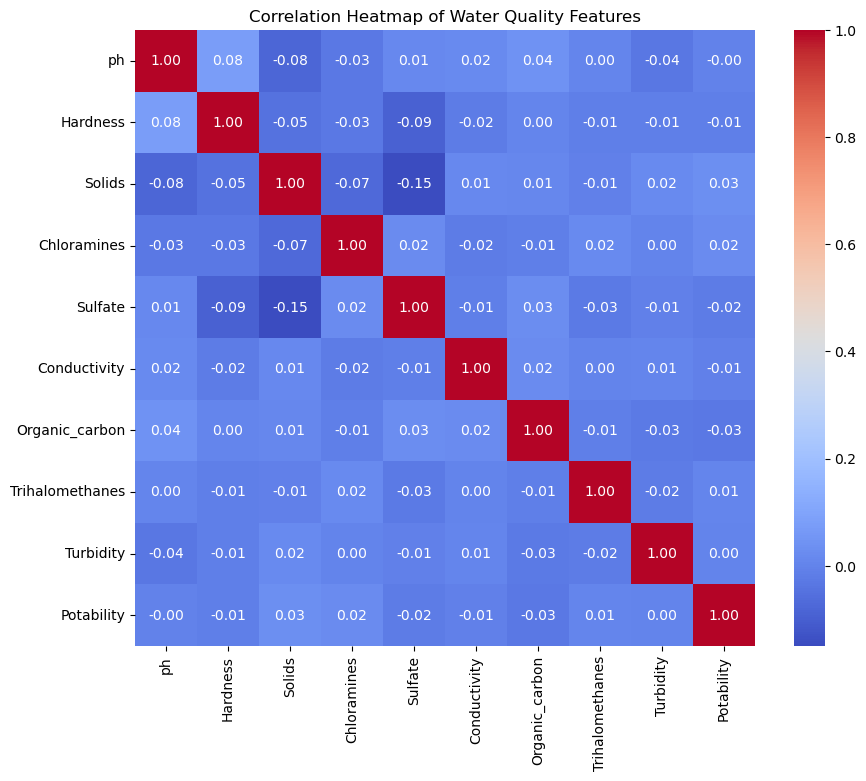

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
# Added numeric_only=True to skip the 'Risk_Analysis' strings
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f') 
plt.title('Correlation Heatmap of Water Quality Features')
plt.show()

In [17]:
from sklearn.model_selection import train_test_split

X = df.drop(['Potability', 'Risk_Analysis'], axis=1) 
y = df['Potability']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

Training samples: 2620
Testing samples: 656


In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Initialize the Model
# n_estimators=100 means we are using 100 individual decision trees
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Train the Model (This is where the "Learning" happens)
rf_model.fit(X_train, y_train)

# 3. Make Predictions on the Test Set
y_pred = rf_model.predict(X_test)

# 4. Check the Results
print(f"Model Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 68.29%

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.86      0.77       412
           1       0.62      0.39      0.48       244

    accuracy                           0.68       656
   macro avg       0.66      0.62      0.62       656
weighted avg       0.67      0.68      0.66       656



C:\Users\asus\AppData\Local\Temp\ipykernel_21476\1679587749.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


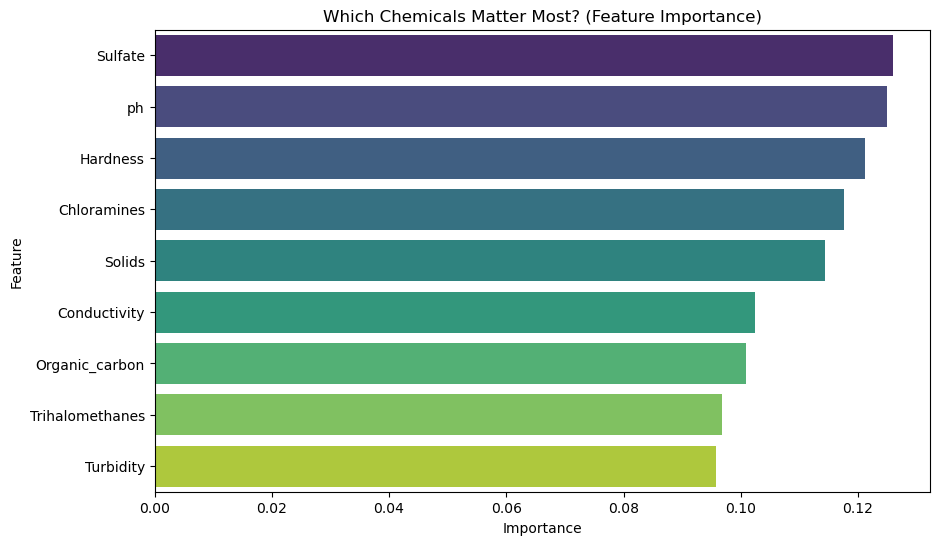

Top 3 most influential chemicals for your dashboard:
    Feature  Importance
4   Sulfate    0.125908
0        ph    0.125003
1  Hardness    0.121126


In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Get feature importance from the trained model
importances = rf_model.feature_importances_
feature_names = X.columns

# 2. Create a DataFrame for visualization
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# 3. Plot the results
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Which Chemicals Matter Most? (Feature Importance)')
plt.show()

# Print the top 3 drivers
print("Top 3 most influential chemicals for your dashboard:")
print(feature_importance_df.head(3))

In [20]:
df.to_csv('Final_Water_Quality_Data.csv', index=False)